In [13]:
import os
import sys
sys.path.append(os.path.abspath('..'))

import yaml
import numpy as np 
import matplotlib.pyplot as plt                     
from src.generate_network import generate_country_network, tension_matrix
from src.scenarios import build_scenarios
from src.action import build_action_effectiveness
from src.qubo import build_qubo, qubo_value
from src.ising import qubo_to_ising, ising_value_from_bits
from src.qulacs_vqe import run_hva_vqe, sample_hva_portfolios
# from src.qubo import best_sampled_portfolios

ImportError: cannot import name '_ReturnT_co' from 'types' (/usr/lib/python3.13/types.py)

In [4]:
with open("../configs/default.yaml", "r") as f:
    config = yaml.safe_load(f)

In [ ]:
J, block = generate_country_network()T = tension_matrix(J)
print(f"Network generated with {J.shape[0]} actors.")

Network generated with 30 actors.


In [6]:
scenarios = build_scenarios(T, block, **config['scenario_params'])
print(f"Generated {len(scenarios)} stress scenarios.")

Generated 10 stress scenarios.


In [7]:
alpha = build_action_effectiveness(block)
print(f"Action effectiveness tensor shape: {alpha.shape}")

Action effectiveness tensor shape: (30, 30, 30)


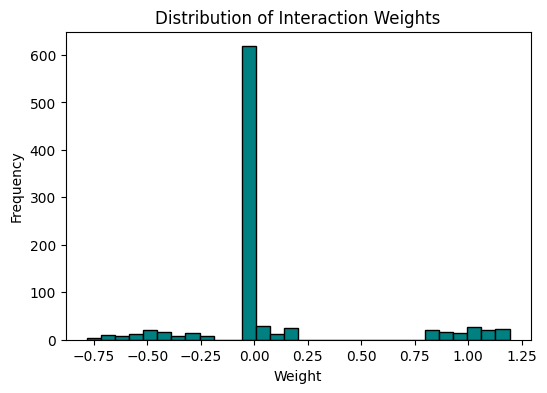

In [8]:
plt.figure(figsize=(6, 4))
plt.hist(J.flatten(), bins=30, color='teal', edgecolor='black')
plt.title("Distribution of Interaction Weights")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()

In [8]:
# Build QUBO
rng = np.random.default_rng(42)
costs = rng.uniform(1.0, 5.0, size=30) 
budget = config['optimization_params']['budget']
eta = config['optimization_params']['eta']

q, Q, const_qubo = build_qubo(scenarios, alpha, costs, budget, eta)

K, g, const_ising = qubo_to_ising(q, Q, const=const_qubo)

In [9]:
# Menggunakan random bitstring untuk menguji ekuivalensi
test_syauqi_bits = rng.integers(0, 2, size=30)

val_qubo = qubo_value(test_syauqi_bits, q, Q, const=const_qubo)
val_ising = ising_value_from_bits(test_syauqi_bits, K, g, c=const_ising)

print(f"QUBO Objective:  {val_qubo:.6f}")
print(f"Ising Objective: {val_ising:.6f}")
assert np.isclose(val_qubo, val_ising), "Mismatch between QUBO and Ising models!"
print("Test Passed: QUBO and Ising formulations are perfectly consistent.")

QUBO Objective:  2148.506877
Ising Objective: 2105.361302


AssertionError: Mismatch between QUBO and Ising models!